In [1]:
import colorcet
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from lib.plots import set_axis, attach_colorbar

In [4]:
task_name = "task-3"
metrics_filename = f"{task_name}/metrics.csv"

metrics_table = pl.read_csv(metrics_filename)

log_transformed_keys = []
derived_metrics_table = (
    metrics_table
    .with_columns(
        **{
            f"log_{key}": np.log10(pl.col(key))
            for key in log_transformed_keys
        }
    )
)

In [5]:
key_labels = {
    "association_valency":        r"$ z $",
    "association_energy":         r"$ \varepsilon_\mathrm{assoc} $",
    "association_constant":       r"$ K_\mathrm{assoc} $",
    "dissociation_rate":          r"$ k_\mathrm{dissoc} $",
    "acetylation_capture_factor": r"Ac. capture eff. $ \gamma_\mathrm{ac} $",
    "acetylation_level":          r"Ac. level $ \phi $",
    "linear_diffusivity":         r"Diffusivity $ k_\mathrm{D} $",
    "release_rate":               r"$ k_\mathrm{release} $",
    "log_release_rate":           r"$ \log_{10} k_\mathrm{release} $",
    "rg":                         r"$ R_\mathrm{g} $",
    "msd_alpha":                  r"MSD exp. $ \alpha $",
    "mean_loop_size":             r"Loop size $ \overline{L} $",
}

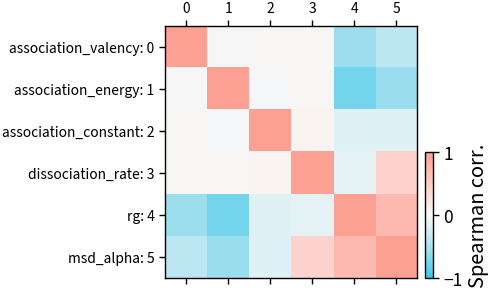

In [9]:
X = (
    metrics_table
    .drop(
        "config_id",
        "mean_cohesins", "mean_captures", "mean_loop_size",
        "msd_alpha_a", "msd_alpha_b",
    )
    .select(pl.all().rank())
    .corr()
)

fig, ax = plt.subplots(figsize=(2.5, 1.5))
sm = ax.matshow(X, vmin=-1, vmax=1, cmap=colorcet.m_cwr)

tick_positions = np.arange(len(X.columns))
tick_labels = [f"{X.columns[i]}: {i}" for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(tick_positions, fontsize="x-small")
ax.set_yticklabels(tick_labels, fontsize="x-small")

cbar = attach_colorbar(ax, sm)
cbar.set_label("Spearman corr.")
pass

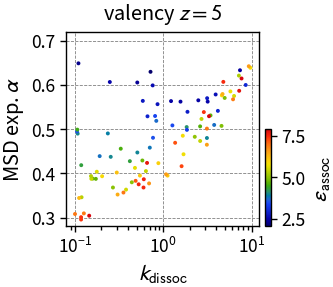

In [24]:
section_valency = 5
section = (
    derived_metrics_table
    .filter(pl.col("association_valency") == section_valency)
)

x_key = "dissociation_rate"
y_key = "msd_alpha"
z_key = "association_energy"

fig, ax = plt.subplots(figsize=(1.4, 1.5))

x = section[x_key]
y = section[y_key]
z = section[z_key]
sm = ax.scatter(x, y, c=z, s=2, ec="none", cmap=colorcet.m_rainbow4, zorder=2)

ax.grid(True, zorder=1)

ax.set_xscale("log")
ax.set_xlabel(key_labels.get(x_key, x_key))
ax.set_ylabel(key_labels.get(y_key, y_key))

ax.set_ylim(0.28, 0.72)
ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7])

cbar = attach_colorbar(ax, sm)
cbar.set_label(key_labels.get(z_key, z_key))

ax.set_title(r"valency $z = {%d}$" % section_valency)

pass